<a href="https://colab.research.google.com/github/Shravani046/Fibroid-Classification/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import os

GH_TOKEN = userdata.get("GH_TOKEN")
GH_USER = "Shravani046"
REPO = "Fibroid-Classification"

!git clone https://{GH_TOKEN}@github.com/{GH_USER}/{REPO}.git

%cd {REPO}
!git pull

Cloning into 'Fibroid-Classification'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 38 (delta 16), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 509.82 KiB | 4.95 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/Fibroid-Classification
Already up to date.


In [ ]:
!pip install -q kagglehub opencv-python-headless

import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from collections import defaultdict
import hashlib
import seaborn as sns

In [ ]:
dataset_path = kagglehub.dataset_download("aureenblessingharazi/fibroid-ultrascans")
print("dataset root:",dataset_path)
for root, dirs, files in os.walk(dataset_path):
  depth = root.replace(dataset_path,'').count(os.sep)
  if depth <3:
    print(""*depth+os.path.basename(root)+"/",f"({len(files)} files" if files else "")

Using Colab cache for faster access to the 'fibroid-ultrascans' dataset.
dataset root: /kaggle/input/fibroid-ultrascans
fibroid-ultrascans/ 
combinedataset/ 
non_fibroid/ (1525 files
fibroid/ (1525 files


In [ ]:
dataset_path = kagglehub.dataset_download("aureenblessingharazi/fibroid-ultrascans")
dataset_path = os.path.join(dataset_path, "combinedataset")

100%|██████████| 132M/132M [00:00<00:00, 140MB/s]

Extracting files...


In [ ]:
records = []

classes = ["fibroid", "non_fibroid"]

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    print(folder)

    if not os.path.isdir(folder):
        print(f"{folder} not found")
        continue

    for fname in os.listdir(folder):
        records.append({
            "path": os.path.join(folder, fname),
            "class": cls,
            "filename": fname
        })

df = pd.DataFrame(records)

print("Total images indexed:", len(df))
df.head()

/root/.cache/kagglehub/datasets/aureenblessingharazi/fibroid-ultrascans/versions/1/combinedataset/fibroid
/root/.cache/kagglehub/datasets/aureenblessingharazi/fibroid-ultrascans/versions/1/combinedataset/non_fibroid
Total images indexed: 3050


,path,class,filename
0,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
1,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
2,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
3,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
4,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid.v1i.yolov8_1-2-826-0-1-3680043...


In [ ]:
def check_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception as e:
        return False

df['is_valid'] = df['path'].apply(check_image)
corrupt = df[~df['is_valid']]

print(f"Corrupt/unreadable files: {len(corrupt)}")
if len(corrupt) > 0:
    print(corrupt[['path', 'split', 'class']])
    # Drop them now so downstream steps aren't affected
    df = df[df['is_valid']].reset_index(drop=True)

Corrupt/unreadable files: 0


In [ ]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Generate hash for every image
df["hash"] = df["path"].apply(file_hash)

# Find duplicate images
dupes = df[df.duplicated("hash", keep=False)].sort_values("hash")

print(f"Total images: {len(df)}")
print(f"Unique images: {df['hash'].nunique()}")
print(f"Duplicate image files: {len(dupes)}")

# Show the most repeated images
print("\nTop repeated hashes:")
print(df["hash"].value_counts().head(10))

# Show duplicate statistics
duplicate_counts = df["hash"].value_counts().value_counts().sort_index()

print("\nDuplicate frequency:")
print(duplicate_counts)

# Preview duplicate images
if len(dupes) > 0:
    print("\nSample duplicate records:")
    print(dupes[["path", "class"]].head(20))

Total images: 3050
Unique images: 2545
Duplicate image files: 905

Top repeated hashes:
hash
d8849a5e21c136fb5b2820e076cc650c    6
64353f96dfc95d2ad3a50345879a93fc    6
54e09e0617a5e83bba92bedb3530d506    5
410124ffb786c198cb2f347d67f55f11    5
52bcb7241dc8f4939862b77b2d136a19    4
2bf8feadc89b374a04a1764904ca1c00    4
9b52d5dbe0b2539ecac2754be8d57021    4
34ac5966bb3d7ec1288f7c6ef2977126    4
5cf6732ddef1c9b10cc1ff1476cae401    4
9e14599960e4a1d087440a5ad7373108    4
Name: count, dtype: int64

Duplicate frequency:
count
1    2145
2     315
3      71
4      10
5       2
6       2
Name: count, dtype: int64

Sample duplicate records:
                                                   path        class
1176  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
374   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
2871  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2561  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
1333  /root/.ca

In [ ]:
# Check if identical images have different labels
label_check = df.groupby("hash")["class"].nunique()

conflicting = label_check[label_check > 1]

print("Conflicting-label hashes:", len(conflicting))

if len(conflicting) > 0:
    bad_hashes = conflicting.index
    print(df[df["hash"].isin(bad_hashes)][["path", "class"]])

Conflicting-label hashes: 5
                                                   path        class
13    /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
134   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
139   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
256   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
801   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
861   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
867   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1462  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1565  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
1954  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2088  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2567  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2603  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2814  

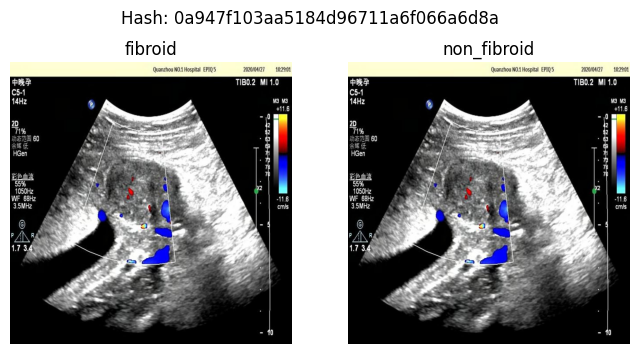

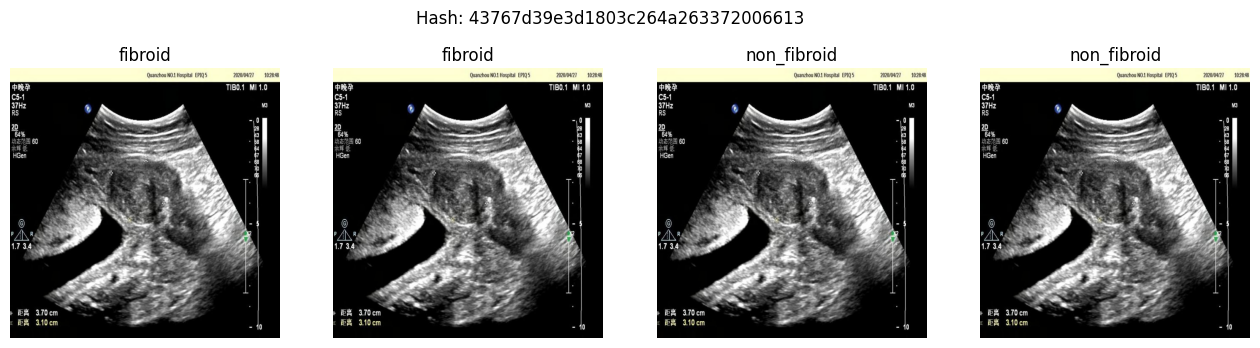

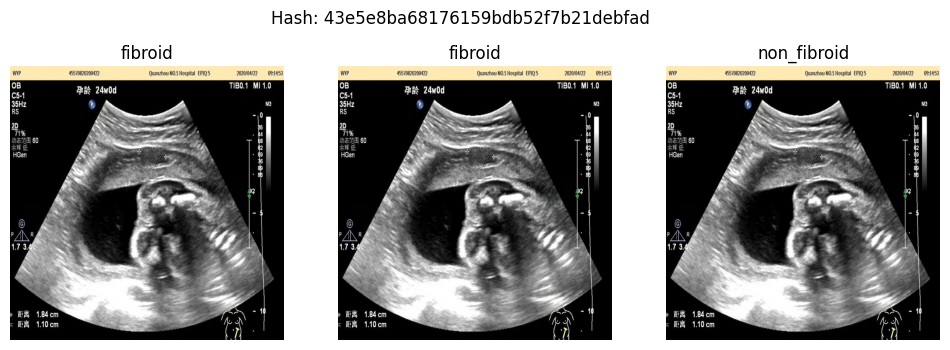

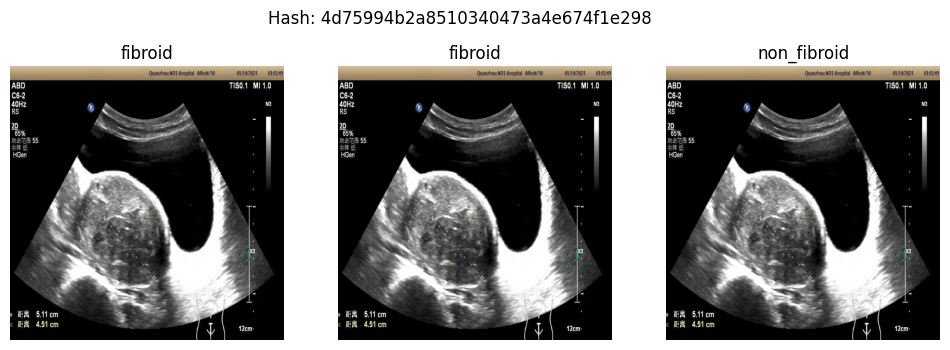

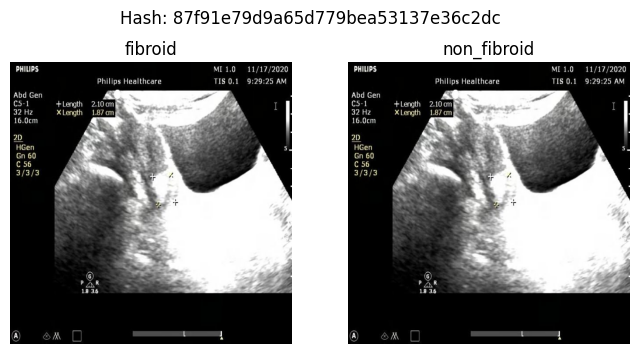

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

bad_hashes = conflicting.index

for h in bad_hashes:
    subset = df[df["hash"] == h]

    fig, axes = plt.subplots(1, len(subset), figsize=(4*len(subset),4))

    if len(subset) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["path"])
        ax.imshow(img, cmap="gray")
        ax.set_title(row["class"])
        ax.axis("off")

    plt.suptitle(f"Hash: {h}")
    plt.show()

In [ ]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['hash'] = df['path'].apply(file_hash)
print(f"Total: {len(df)} | Unique hashes: {df['hash'].nunique()}")
# Conflicting hashes: same image, different class labels
hash_class_counts = df.groupby('hash')['class'].nunique()
conflicting_hashes = hash_class_counts[hash_class_counts > 1].index.tolist()

print(f"Conflicting hashes (same image, different labels): {len(conflicting_hashes)}")
conflict_rows = df[df['hash'].isin(conflicting_hashes)].sort_values('hash')
print(conflict_rows[['path', 'class', 'hash']])

Total: 3050 | Unique hashes: 2545
Conflicting hashes (same image, different labels): 5
                                                   path        class  \
867   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1565  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
139   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
801   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
2088  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
2814  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
861   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1462  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
2603  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
13    /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
134   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1954  /root/.cache/kagglehub/datasets/aureenbless

In [ ]:
# Pass 1: drop every copy of a conflicting-hash image entirely (label is unreliable, not salvageable by keeping one)
df_clean = df[~df['hash'].isin(conflicting_hashes)].copy()
print(f"After removing conflicts: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

# Pass 2: deduplicate remaining — keep first occurrence per hash
df_dedup = df_clean.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)
print(f"After deduplication: {len(df_dedup)} (dropped {len(df_clean) - len(df_dedup)} duplicate copies)")

print("\nFinal class balance:")
print(df_dedup['class'].value_counts())

After removing conflicts: 3036 (dropped 14)
After deduplication: 2540 (dropped 496 duplicate copies)

Final class balance:
class
non_fibroid    1456
fibroid        1084
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df_dedup,
    test_size=0.30,
    stratify=df_dedup['class'],
    random_state=42
)

# Second split: temp → 15% valid, 15% test (i.e., 50/50 of the 30%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class'],
    random_state=42
)

train_df = train_df.copy(); train_df['split'] = 'train'
valid_df = valid_df.copy(); valid_df['split'] = 'valid'
test_df = test_df.copy(); test_df['split'] = 'test'

split_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print(split_df.groupby(['split', 'class']).size().unstack())

class  fibroid  non_fibroid
split                      
test       163          218
train      759         1019
valid      162          219


In [ ]:
train_hashes = set(train_df['hash'])
valid_hashes = set(valid_df['hash'])
test_hashes = set(test_df['hash'])

leak_train_valid = train_hashes & valid_hashes
leak_train_test = train_hashes & test_hashes
leak_valid_test = valid_hashes & test_hashes

print(f"Train∩Valid leakage: {len(leak_train_valid)}")
print(f"Train∩Test leakage:  {len(leak_train_test)}")
print(f"Valid∩Test leakage:  {len(leak_valid_test)}")

assert len(leak_train_valid) == 0, "LEAKAGE DETECTED: train/valid overlap"
assert len(leak_train_test) == 0, "LEAKAGE DETECTED: train/test overlap"
assert len(leak_valid_test) == 0, "LEAKAGE DETECTED: valid/test overlap"
print("\nZero leakage confirmed across all splits.")

Train∩Valid leakage: 0
Train∩Test leakage:  0
Valid∩Test leakage:  0

Zero leakage confirmed across all splits.


In [ ]:
import shutil

output_root = 'data/splits'

for split in ['train', 'valid', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

for _, row in split_df.iterrows():
    dest = os.path.join(output_root, row['split'], row['class'], row['filename'])
    shutil.copy2(row['path'], dest)

print("Split folders created at:", output_root)

Split folders created at: data/splits


In [ ]:
original_df = df.copy()

In [ ]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [50]:
import os

os.makedirs("data", exist_ok=True)

split_df.to_csv("data/eda_inventory_final.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [51]:
!find . -name "eda_inventory_final.csv"

./data/eda_inventory_final.csv


In [52]:
!git pull --rebase origin main

From https://github.com/Shravani046/Fibroid-Classification
 * branch            main       -> FETCH_HEAD
Already up to date.


In [54]:
!find . -name "eda_inventory_final.csv"

./data/eda_inventory_final.csv


In [53]:
!git add data/eda_inventory_final.csv
!git add .gitignore
!git commit -m "data: add cleaned EDA inventory"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [56]:
!git log --oneline -5

fa79d99 (HEAD -> main, origin/main, origin/HEAD) data: add cleaned EDA inventory
ac7f9df Implemented dataset cleaning and analysis
991a5fd Update .gitignore to exclude data/splits/
4ceca60 Update .gitignore to include data/splits
4cbd952 Update .gitignore to keep specific data files
